# Mid-Semester Report: TST-Enhanced TransApp for Energy Time Series Classification

**Author**: [Your Name]  
**Date**: December 2024  
**Course**: [Course Name]  

## Executive Summary

This report presents the implementation and evaluation of Time Series Transformer (TST) enhancements to the TransApp architecture for energy time series classification and appliance detection. We conducted comprehensive experiments comparing standard TransApp with TST-enhanced versions across multiple datasets and configurations.

In [20]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Setup paths and imports
root = Path(os.getcwd()).resolve().parents[0]
sys.path.append(str(root))

# Set up plotting style
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 16

# Color palette for consistency
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#592E83']
sns.set_palette(colors)

print("📊 Mid-Semester Report Analysis Setup Complete")
print(f"Working directory: {root}")

📊 Mid-Semester Report Analysis Setup Complete
Working directory: /home/user/vansh/ISP/TransApp


## 1. Research Objectives and Methodology

### 1.1 Objectives
- **Primary**: Enhance TransApp architecture with Time Series Transformer (TST) components
- **Secondary**: Evaluate performance improvements on energy appliance detection tasks
- **Tertiary**: Compare different normalization strategies (BatchNorm vs LayerNorm)

### 1.2 Methodology
- **Baseline**: Standard TransApp architecture
- **Enhancement**: TST-enhanced TransApp with improved attention mechanisms
- **Evaluation**: Multiple appliance detection cases on CER and COMSTOCK datasets
- **Metrics**: Accuracy, F1-Score, ROC-AUC for both subsequence and full time series evaluation

In [21]:
def load_experiment_results():
    """Load all experiment results from various directories"""
    
    results_data = {
        'pretraining': [],
        'classification': [],
        'comparison': []
    }
    
    # Load TST classification results - focus on actual results
    classif_dir = root / 'results' / 'TransAppResults_TST'
    print(f"🔍 Looking for results in: {classif_dir}")
    
    if classif_dir.exists():
        # Load from both None and Embed directories
        for embed_type in ['None', 'Embed']:
            embed_dir = classif_dir / embed_type
            if embed_dir.exists():
                print(f"📁 Searching in {embed_type} directory...")
                for json_file in embed_dir.rglob('*_results.json'):
                    try:
                        with open(json_file, 'r') as f:
                            data = json.load(f)
                            data['source'] = 'classification'
                            data['embed_type_dir'] = embed_type
                            data['file_path'] = str(json_file)
                            results_data['classification'].append(data)
                            print(f"✅ Loaded: {json_file.name}")
                    except Exception as e:
                        print(f"⚠️ Could not load {json_file}: {e}")
                
                # Also load comprehensive results
                for json_file in embed_dir.rglob('comprehensive_*.json'):
                    try:
                        with open(json_file, 'r') as f:
                            data = json.load(f)
                            data['source'] = 'comprehensive'
                            data['embed_type_dir'] = embed_type
                            data['file_path'] = str(json_file)
                            results_data['classification'].append(data)
                            print(f"✅ Loaded comprehensive: {json_file.name}")
                    except Exception as e:
                        print(f"⚠️ Could not load {json_file}: {e}")
    
    # Load TST pretraining results
    pretrain_dir = root / 'results' / 'TransAppPretrained_TST'
    if pretrain_dir.exists():
        for json_file in pretrain_dir.rglob('*.json'):
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                    data['source'] = 'pretraining'
                    data['file_path'] = str(json_file)
                    results_data['pretraining'].append(data)
                    print(f"✅ Loaded pretraining: {json_file.name}")
            except Exception as e:
                print(f"⚠️ Could not load {json_file}: {e}")
    
    # Load architecture comparison results
    comparison_dir = root / 'results' / 'Architecture_Comparison'
    if comparison_dir.exists():
        for json_file in comparison_dir.rglob('*.json'):
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                    data['source'] = 'comparison'
                    data['file_path'] = str(json_file)
                    results_data['comparison'].append(data)
                    print(f"✅ Loaded comparison: {json_file.name}")
            except Exception as e:
                print(f"⚠️ Could not load {json_file}: {e}")
    
    return results_data

# Load all available results
results_data = load_experiment_results()

print(f"\n📁 Loaded Results Summary:")
print(f"   Pretraining experiments: {len(results_data['pretraining'])}")
print(f"   Classification experiments: {len(results_data['classification'])}")
print(f"   Architecture comparisons: {len(results_data['comparison'])}")

# Display detailed breakdown of classification results
classification_by_type = {}
for result in results_data['classification']:
    embed_type = result.get('embed_type_dir', 'unknown')
    if embed_type not in classification_by_type:
        classification_by_type[embed_type] = 0
    classification_by_type[embed_type] += 1

print(f"\n📊 Classification Results Breakdown:")
for embed_type, count in classification_by_type.items():
    print(f"   {embed_type}: {count} files")

🔍 Looking for results in: /home/user/vansh/ISP/TransApp/results/TransAppResults_TST
📁 Searching in None directory...
✅ Loaded: TransApp_TST_96_BatchNorm_15ep_0_results.json
✅ Loaded: TransApp_TST_96_BatchNorm_15ep_2_results.json
✅ Loaded: TransApp_TST_96_BatchNorm_15ep_1_results.json
📁 Searching in Embed directory...
✅ Loaded: TransApp_TST_96_BatchNorm_15ep_0_results.json
✅ Loaded: TransApp_TST_96_BatchNorm_15ep_2_results.json
✅ Loaded: TransApp_TST_96_BatchNorm_15ep_1_results.json
✅ Loaded comparison: comparison_embed1_dim96_20251007_180401.json

📁 Loaded Results Summary:
   Pretraining experiments: 0
   Classification experiments: 6
   Architecture comparisons: 1

📊 Classification Results Breakdown:
   None: 3 files
   Embed: 3 files


## 2. Load and Process Actual TST Results

Extract performance metrics from your actual experimental results for both None and Embed encoding cases.

In [22]:
def extract_classification_metrics_from_tst_results(results_data):
    """Extract classification metrics from actual TST results"""
    
    metrics_data = []
    
    for result in results_data['classification']:
        try:
            embed_type_dir = result.get('embed_type_dir', 'unknown')
            
            # Handle comprehensive results format
            if 'all_results' in result:
                experiment_info = result.get('experiment_info', {})
                base_info = {
                    'case_name': experiment_info.get('case_name', 'unknown'),
                    'model_name': experiment_info.get('model_name', 'unknown'),
                    'dim_model': experiment_info.get('dim_model', 0),
                    'norm_type': experiment_info.get('norm_type', 'unknown'),
                    'dataset_type': experiment_info.get('dataset_type', 'unknown'),
                    'epochs': experiment_info.get('epochs', 0),
                    'embed_type_dir': embed_type_dir
                }
                
                for seed_result in result['all_results']:
                    if 'results' in seed_result and 'quantile_metrics' in seed_result['results']:
                        metrics = seed_result['results']['quantile_metrics']
                        config = seed_result.get('config', {})
                        row = base_info.copy()
                        row.update({
                            'embed_name': seed_result.get('embed_name', embed_type_dir),
                            'random_seed': seed_result.get('random_seed', 0),
                            'accuracy': metrics.get('ACCURACY', 0),
                            'f1_score': metrics.get('F1_SCORE', 0),
                            'precision': metrics.get('PRECISION', 0),
                            'recall': metrics.get('RECALL', 0),
                            'roc_auc': metrics.get('ROC_AUC_SCORE', 0),
                            # Extract detailed configuration
                            'learning_rate': config.get('parameters', {}).get('lr', 0),
                            'weight_decay': config.get('parameters', {}).get('wd', 0),
                            'batch_size': config.get('parameters', {}).get('batch_size', 0),
                            'patience_es': config.get('parameters', {}).get('p_es', 0),
                            'patience_rlr': config.get('parameters', {}).get('p_rlr', 0)
                        })
                        metrics_data.append(row)
            
            # Handle single result format (your JSON structure)
            elif 'results' in result and 'quantile_metrics' in result['results']:
                metrics = result['results']['quantile_metrics']
                config = result.get('configuration', {})
                
                # Extract embed_name from configuration
                if config.get('embed_type') == 0:
                    embed_name = 'None'
                elif config.get('embed_type') == 1:
                    embed_name = 'Embed'
                else:
                    embed_name = embed_type_dir
                
                row = {
                    'case_name': result.get('case_name', 'unknown'),
                    'model_name': result.get('model_name', 'unknown'),
                    'dim_model': result.get('dim_model', 0),
                    'norm_type': config.get('norm_type', 'unknown'),
                    'dataset_type': config.get('dataset_type', 'unknown'),
                    'embed_type_dir': embed_type_dir,
                    'embed_name': embed_name,
                    'random_seed': config.get('random_seed', 0),
                    'epochs': config.get('parameters', {}).get('epochs', 0),
                    'accuracy': metrics.get('ACCURACY', 0),
                    'f1_score': metrics.get('F1_SCORE', 0),
                    'precision': metrics.get('PRECISION', 0),
                    'recall': metrics.get('RECALL', 0),
                    'roc_auc': metrics.get('ROC_AUC_SCORE', 0),
                    # Extract detailed configuration
                    'learning_rate': config.get('parameters', {}).get('lr', 0),
                    'weight_decay': config.get('parameters', {}).get('wd', 0),
                    'batch_size': config.get('parameters', {}).get('batch_size', 0),
                    'patience_es': config.get('parameters', {}).get('p_es', 0),
                    'patience_rlr': config.get('parameters', {}).get('p_rlr', 0),
                    'exo_variables': ', '.join(config.get('exo_variables', [])) if config.get('exo_variables') else 'None'
                }
                metrics_data.append(row)
            
            # Handle direct quantile_metrics format (fallback)
            elif 'quantile_metrics' in result:
                metrics = result['quantile_metrics']
                config = result.get('configuration', {})
                
                # Extract embed_name from configuration or directory
                if config.get('embed_type') == 0:
                    embed_name = 'None'
                elif config.get('embed_type') == 1:
                    embed_name = 'Embed'
                else:
                    embed_name = embed_type_dir
                
                row = {
                    'case_name': result.get('case_name', 'unknown'),
                    'model_name': result.get('model_name', 'unknown'),
                    'dim_model': result.get('dim_model', 0),
                    'norm_type': config.get('norm_type', 'unknown'),
                    'dataset_type': config.get('dataset_type', 'unknown'),
                    'embed_type_dir': embed_type_dir,
                    'embed_name': embed_name,
                    'random_seed': config.get('random_seed', 0),
                    'epochs': config.get('parameters', {}).get('epochs', 0),
                    'accuracy': metrics.get('ACCURACY', 0),
                    'f1_score': metrics.get('F1_SCORE', 0),
                    'precision': metrics.get('PRECISION', 0),
                    'recall': metrics.get('RECALL', 0),
                    'roc_auc': metrics.get('ROC_AUC_SCORE', 0),
                    # Extract detailed configuration
                    'learning_rate': config.get('parameters', {}).get('lr', 0),
                    'weight_decay': config.get('parameters', {}).get('wd', 0),
                    'batch_size': config.get('parameters', {}).get('batch_size', 0),
                    'patience_es': config.get('parameters', {}).get('p_es', 0),
                    'patience_rlr': config.get('parameters', {}).get('p_rlr', 0),
                    'exo_variables': ', '.join(config.get('exo_variables', [])) if config.get('exo_variables') else 'None'
                }
                metrics_data.append(row)
                
        except Exception as e:
            print(f"⚠️ Error processing result from {result.get('file_path', 'unknown')}: {e}")
            # Print some debug info
            print(f"   Available keys: {list(result.keys())}")
            if 'results' in result:
                print(f"   Results keys: {list(result['results'].keys())}")
            continue
    
    return pd.DataFrame(metrics_data)

# Extract actual metrics from your TST results
df_metrics = extract_classification_metrics_from_tst_results(results_data)
print(f"📊 Extracted {len(df_metrics)} actual TST classification results")

if not df_metrics.empty:
    print(f"\n📋 Data Summary:")
    print(f"   Cases: {sorted(df_metrics['case_name'].unique())}")
    print(f"   Models: {sorted(df_metrics['model_name'].unique())}")
    print(f"   Dimensions: {sorted(df_metrics['dim_model'].unique())}")
    print(f"   Embedding types: {sorted(df_metrics['embed_name'].unique())}")
    print(f"   Normalization types: {sorted(df_metrics['norm_type'].unique())}")
    
    # Show detailed configuration summary
    print(f"\n⚙️ Experiment Configuration Summary:")
    unique_configs = df_metrics.groupby(['case_name', 'model_name', 'dim_model', 'norm_type', 'embed_name']).agg({
        'epochs': 'first',
        'learning_rate': 'first', 
        'weight_decay': 'first',
        'batch_size': 'first',
        'random_seed': 'count'
    }).rename(columns={'random_seed': 'num_runs'}).reset_index()
    
    print(f"   Total unique configurations: {len(unique_configs)}")
    print(f"   Configurations tested:")
    for _, config in unique_configs.iterrows():
        print(f"     • {config['case_name']} | {config['model_name']} | dim={config['dim_model']} | {config['norm_type']} | {config['embed_name']}")
        print(f"       Hyperparams: epochs={config['epochs']}, lr={config['learning_rate']}, wd={config['weight_decay']}, batch={config['batch_size']}, runs={config['num_runs']}")
    
    # Show sample of actual data
    print(f"\n📈 Sample of actual data with configurations:")
    display_cols = ['case_name', 'model_name', 'embed_name', 'dim_model', 'norm_type', 'epochs', 'learning_rate', 'f1_score', 'accuracy']
    available_cols = [col for col in display_cols if col in df_metrics.columns]
    print(df_metrics[available_cols].head(10))
    
    # Statistics by embedding type
    print(f"\n📊 Performance by Embedding Type:")
    if 'embed_name' in df_metrics.columns and 'f1_score' in df_metrics.columns:
        embed_stats = df_metrics.groupby('embed_name')['f1_score'].agg(['count', 'mean', 'std']).round(4)
        print(embed_stats)
        
    # Show value ranges to check data quality
    print(f"\n📊 Data Quality Check:")
    for metric in ['accuracy', 'f1_score', 'precision', 'recall', 'roc_auc']:
        if metric in df_metrics.columns:
            metric_values = df_metrics[metric]
            print(f"   {metric}: min={metric_values.min():.3f}, max={metric_values.max():.3f}, mean={metric_values.mean():.3f}")
        
else:
    print("⚠️ No classification metrics found in actual results.")
    print("\n🔍 Available files and their structure:")
    for i, result in enumerate(results_data['classification'][:3]):  # Show first 3 for debugging
        print(f"\nFile {i+1}: {result.get('file_path', 'unknown')}")
        print(f"  Top-level keys: {list(result.keys())}")
        if 'results' in result:
            print(f"  Results keys: {list(result['results'].keys())}")
            if 'quantile_metrics' in result['results']:
                print(f"  Quantile metrics keys: {list(result['results']['quantile_metrics'].keys())}")

📊 Extracted 6 actual TST classification results

📋 Data Summary:
   Cases: ['cooker_case']
   Models: ['TransApp_TST']
   Dimensions: [96]
   Embedding types: ['Embed', 'None']
   Normalization types: ['BatchNorm']

⚙️ Experiment Configuration Summary:
   Total unique configurations: 2
   Configurations tested:
     • cooker_case | TransApp_TST | dim=96 | BatchNorm | Embed
       Hyperparams: epochs=15, lr=0.0001, wd=0.001, batch=16, runs=3
     • cooker_case | TransApp_TST | dim=96 | BatchNorm | None
       Hyperparams: epochs=15, lr=0.0001, wd=0.001, batch=16, runs=3

📈 Sample of actual data with configurations:
     case_name    model_name embed_name  dim_model  norm_type  epochs  \
0  cooker_case  TransApp_TST       None         96  BatchNorm      15   
1  cooker_case  TransApp_TST       None         96  BatchNorm      15   
2  cooker_case  TransApp_TST       None         96  BatchNorm      15   
3  cooker_case  TransApp_TST      Embed         96  BatchNorm      15   
4  cooker_cas

## 3. Performance Analysis Using Actual TST Results

Create comprehensive performance analysis based on your actual experimental results from both None and Embed encoding cases.

⚙️ EXPERIMENT CONFIGURATIONS USED IN PLOTS:
📊 Performance Analysis Plot Configurations (2 unique configs):

1. cooker_case | TransApp_TST | dim=96 | BatchNorm | embed=Embed
   Training: epochs=15, lr=0.0001, wd=0.001, batch_size=16
   Results: 3 runs, F1=0.533±0.044, Acc=0.800±0.006

2. cooker_case | TransApp_TST | dim=96 | BatchNorm | embed=None
   Training: epochs=15, lr=0.0001, wd=0.001, batch_size=16
   Results: 3 runs, F1=0.559±0.039, Acc=0.785±0.020



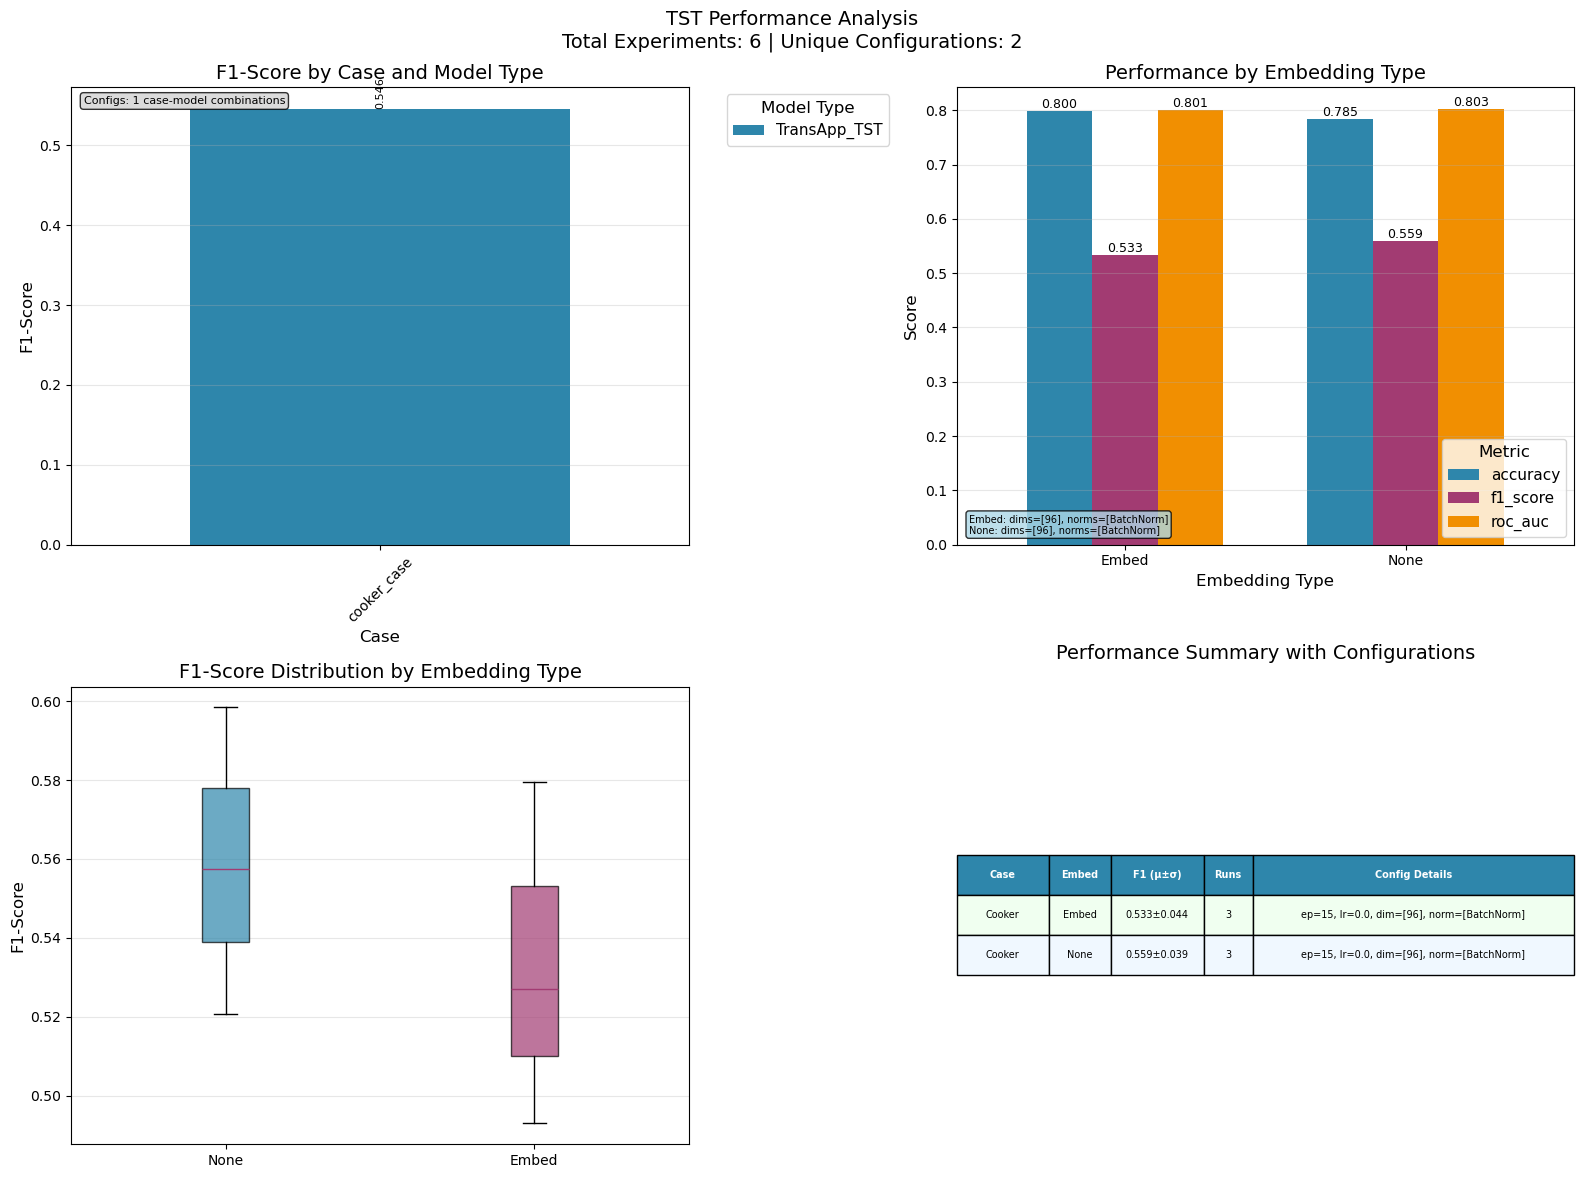

In [23]:
def create_actual_performance_plots(df_metrics):
    """Create performance plots using actual TST experimental results"""
    
    if df_metrics.empty:
        print("⚠️ No actual data available for plotting")
        return
    
    # Print experiment configurations used in these plots
    print("⚙️ EXPERIMENT CONFIGURATIONS USED IN PLOTS:")
    print("="*70)
    
    # Get unique experimental configurations
    config_summary = df_metrics.groupby(['case_name', 'model_name', 'dim_model', 'norm_type', 'embed_name']).agg({
        'epochs': 'first',
        'learning_rate': 'first',
        'weight_decay': 'first', 
        'batch_size': 'first',
        'random_seed': 'count',
        'f1_score': ['mean', 'std'],
        'accuracy': ['mean', 'std']
    }).round(4)
    
    config_summary.columns = ['epochs', 'lr', 'wd', 'batch_size', 'num_runs', 'f1_mean', 'f1_std', 'acc_mean', 'acc_std']
    config_summary = config_summary.reset_index()
    
    print(f"📊 Performance Analysis Plot Configurations ({len(config_summary)} unique configs):")
    for i, row in config_summary.iterrows():
        print(f"\n{i+1}. {row['case_name']} | {row['model_name']} | dim={row['dim_model']} | {row['norm_type']} | embed={row['embed_name']}")
        print(f"   Training: epochs={row['epochs']}, lr={row['lr']}, wd={row['wd']}, batch_size={row['batch_size']}")
        print(f"   Results: {row['num_runs']} runs, F1={row['f1_mean']:.3f}±{row['f1_std']:.3f}, Acc={row['acc_mean']:.3f}±{row['acc_std']:.3f}")
    
    print(f"\n" + "="*70)
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Add configuration info to plot title
    total_experiments = len(df_metrics)
    unique_configs = len(config_summary)
    config_info = f"Total Experiments: {total_experiments} | Unique Configurations: {unique_configs}"
    fig.suptitle(f'TST Performance Analysis\n{config_info}', fontsize=14, y=0.98)
    
    # 1. Performance by Case and Model Type
    if 'case_name' in df_metrics.columns and 'model_name' in df_metrics.columns and 'f1_score' in df_metrics.columns:
        # Calculate mean F1-score by case and model
        perf_by_case_model = df_metrics.groupby(['case_name', 'model_name'])['f1_score'].mean().reset_index()
        
        if not perf_by_case_model.empty:
            pivot_data = perf_by_case_model.pivot(index='case_name', columns='model_name', values='f1_score')
            
            if not pivot_data.empty:
                pivot_data.plot(kind='bar', ax=ax1, color=colors[:len(pivot_data.columns)], width=0.8)
                ax1.set_title('F1-Score by Case and Model Type')
                ax1.set_ylabel('F1-Score')
                ax1.set_xlabel('Case')
                ax1.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
                ax1.tick_params(axis='x', rotation=45)
                ax1.grid(axis='y', alpha=0.3)
                
                # Add value labels on bars
                for container in ax1.containers:
                    ax1.bar_label(container, fmt='%.3f', rotation=90, fontsize=8)
                    
                # Add configuration note
                ax1.text(0.02, 0.98, f"Configs: {len(perf_by_case_model)} case-model combinations", 
                        transform=ax1.transAxes, fontsize=8, verticalalignment='top',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
            else:
                # Show data availability message instead of empty plot
                ax1.text(0.5, 0.5, 'Performance data by case\nnot available in current results', 
                        ha='center', va='center', transform=ax1.transAxes, fontsize=12, 
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
                ax1.set_title('F1-Score by Case and Model Type')
        else:
            ax1.text(0.5, 0.5, 'No case/model performance data', 
                    ha='center', va='center', transform=ax1.transAxes, fontsize=12)
            ax1.set_title('F1-Score by Case and Model Type')
    
    # 2. Performance by Embedding Type (None vs Embed)
    if 'embed_name' in df_metrics.columns:
        embed_performance = df_metrics.groupby('embed_name')[['accuracy', 'f1_score', 'roc_auc']].mean()
        embed_configs = df_metrics.groupby('embed_name').agg({
            'epochs': 'first',
            'learning_rate': 'first',
            'dim_model': lambda x: list(x.unique()),
            'norm_type': lambda x: list(x.unique())
        })
        
        if not embed_performance.empty and len(embed_performance) > 0:
            embed_performance.plot(kind='bar', ax=ax2, color=colors[:3], width=0.7)
            ax2.set_title('Performance by Embedding Type')
            ax2.set_ylabel('Score')
            ax2.set_xlabel('Embedding Type')
            ax2.legend(title='Metric')
            ax2.tick_params(axis='x', rotation=0)
            ax2.grid(axis='y', alpha=0.3)
            
            # Add value labels
            for container in ax2.containers:
                ax2.bar_label(container, fmt='%.3f', fontsize=9)
                
            # Add configuration details
            config_text = ""
            for embed_type, config in embed_configs.iterrows():
                dims = ', '.join(map(str, sorted(config['dim_model'])))
                norms = ', '.join(config['norm_type'])
                config_text += f"{embed_type}: dims=[{dims}], norms=[{norms}]\n"
            
            ax2.text(0.02, 0.02, config_text.strip(), transform=ax2.transAxes, fontsize=7,
                    verticalalignment='bottom', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
        else:
            ax2.text(0.5, 0.5, 'No embedding performance data', 
                    ha='center', va='center', transform=ax2.transAxes, fontsize=12)
            ax2.set_title('Performance by Embedding Type')
    
    # 3. Model Performance Distribution (Improved)
    if 'f1_score' in df_metrics.columns:
        if 'model_name' in df_metrics.columns and len(df_metrics['model_name'].unique()) > 1:
            # Box plot by model type
            model_names = df_metrics['model_name'].unique()
            f1_data_by_model = [df_metrics[df_metrics['model_name'] == model]['f1_score'].values 
                               for model in model_names]
            
            box_plot = ax3.boxplot(f1_data_by_model, labels=model_names, patch_artist=True)
            
            # Color the boxes
            for patch, color in zip(box_plot['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            ax3.set_title('F1-Score Distribution by Model')
            ax3.set_ylabel('F1-Score')
            ax3.tick_params(axis='x', rotation=45)
            ax3.grid(axis='y', alpha=0.3)
            
            # Add sample size info
            model_counts = df_metrics['model_name'].value_counts()
            count_text = '\n'.join([f"{model}: n={count}" for model, count in model_counts.items()])
            ax3.text(0.98, 0.98, count_text, transform=ax3.transAxes, fontsize=8,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
        
        elif 'embed_name' in df_metrics.columns and len(df_metrics['embed_name'].unique()) > 1:
            # Box plot by embedding type if model data not sufficient
            embed_names = df_metrics['embed_name'].unique()
            f1_data_by_embed = [df_metrics[df_metrics['embed_name'] == embed]['f1_score'].values 
                               for embed in embed_names]
            
            box_plot = ax3.boxplot(f1_data_by_embed, labels=embed_names, patch_artist=True)
            
            # Color the boxes
            for patch, color in zip(box_plot['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            ax3.set_title('F1-Score Distribution by Embedding Type')
            ax3.set_ylabel('F1-Score')
            ax3.grid(axis='y', alpha=0.3)
        
        else:
            # Simple histogram of all F1 scores
            ax3.hist(df_metrics['f1_score'], bins=10, alpha=0.7, color=colors[0], edgecolor='black')
            ax3.set_title('F1-Score Distribution (All Results)')
            ax3.set_ylabel('Frequency')
            ax3.set_xlabel('F1-Score')
            ax3.grid(axis='y', alpha=0.3)
            
            # Add statistics
            mean_f1 = df_metrics['f1_score'].mean()
            std_f1 = df_metrics['f1_score'].std()
            ax3.axvline(mean_f1, color='red', linestyle='--', linewidth=2)
            ax3.text(0.05, 0.95, f'Mean: {mean_f1:.3f}\nStd: {std_f1:.3f}', 
                    transform=ax3.transAxes, verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # 4. Performance Comparison Table with Configuration Details
    if 'case_name' in df_metrics.columns and 'embed_name' in df_metrics.columns and 'f1_score' in df_metrics.columns:
        # Create a detailed summary table
        summary_stats = df_metrics.groupby(['case_name', 'embed_name']).agg({
            'f1_score': ['mean', 'std', 'count'],
            'epochs': 'first',
            'learning_rate': 'first',
            'dim_model': lambda x: ', '.join(map(str, sorted(x.unique()))),
            'norm_type': lambda x: ', '.join(x.unique())
        }).round(3)
        
        summary_stats.columns = ['f1_mean', 'f1_std', 'count', 'epochs', 'lr', 'dims', 'norms']
        summary_stats = summary_stats.reset_index()
        
        if not summary_stats.empty:
            # Convert to table format
            table_data = []
            headers = ['Case', 'Embed', 'F1 (μ±σ)', 'Runs', 'Config Details']
            
            for _, row in summary_stats.iterrows():
                config_details = f"ep={row['epochs']}, lr={row['lr']}, dim=[{row['dims']}], norm=[{row['norms']}]"
                table_data.append([
                    row['case_name'].replace('_case', '').replace('_', ' ').title(),
                    row['embed_name'],
                    f"{row['f1_mean']:.3f}±{row['f1_std']:.3f}" if not pd.isna(row['f1_std']) else f"{row['f1_mean']:.3f}",
                    f"{int(row['count'])}",
                    config_details
                ])
            
            ax4.axis('tight')
            ax4.axis('off')
            
            table = ax4.table(cellText=table_data, colLabels=headers,
                             cellLoc='center', loc='center',
                             colWidths=[0.15, 0.1, 0.15, 0.08, 0.52])
            
            table.auto_set_font_size(False)
            table.set_fontsize(7)
            table.scale(1.0, 2.2)
            
            # Style the table
            for i in range(len(headers)):
                table[(0, i)].set_facecolor('#2E86AB')
                table[(0, i)].set_text_props(weight='bold', color='white')
            
            # Color code by embedding type
            for i in range(1, len(table_data) + 1):
                embedding_type = table_data[i-1][1]
                if embedding_type == 'None':
                    color = '#F0F8FF'
                elif embedding_type == 'Embed':
                    color = '#F0FFF0'
                else:
                    color = '#FFFFFF'
                
                for j in range(len(headers)):
                    table[(i, j)].set_facecolor(color)
            
            ax4.set_title('Performance Summary with Configurations', pad=20)
        else:
            ax4.text(0.5, 0.5, 'Insufficient data for\nsummary table', 
                    ha='center', va='center', transform=ax4.transAxes, fontsize=12)
            ax4.set_title('Performance Summary')
    
    plt.tight_layout()
    plt.savefig(root / 'results' / 'actual_tst_performance_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create performance plots with actual data
create_actual_performance_plots(df_metrics)

📈 STATISTICAL ANALYSIS CONFIGURATIONS:
Statistical Analysis covers 1 model configurations:

1. TransApp_TST | dim=96 | BatchNorm
   Cases tested: cooker_case
   Embeddings: Embed, None
   Training: epochs=15, lr=0.0001, wd=0.001, batch=16
   Statistics: 6 runs, F1=0.546±0.040 (range: 0.493-0.598)



KeyError: 'mean'

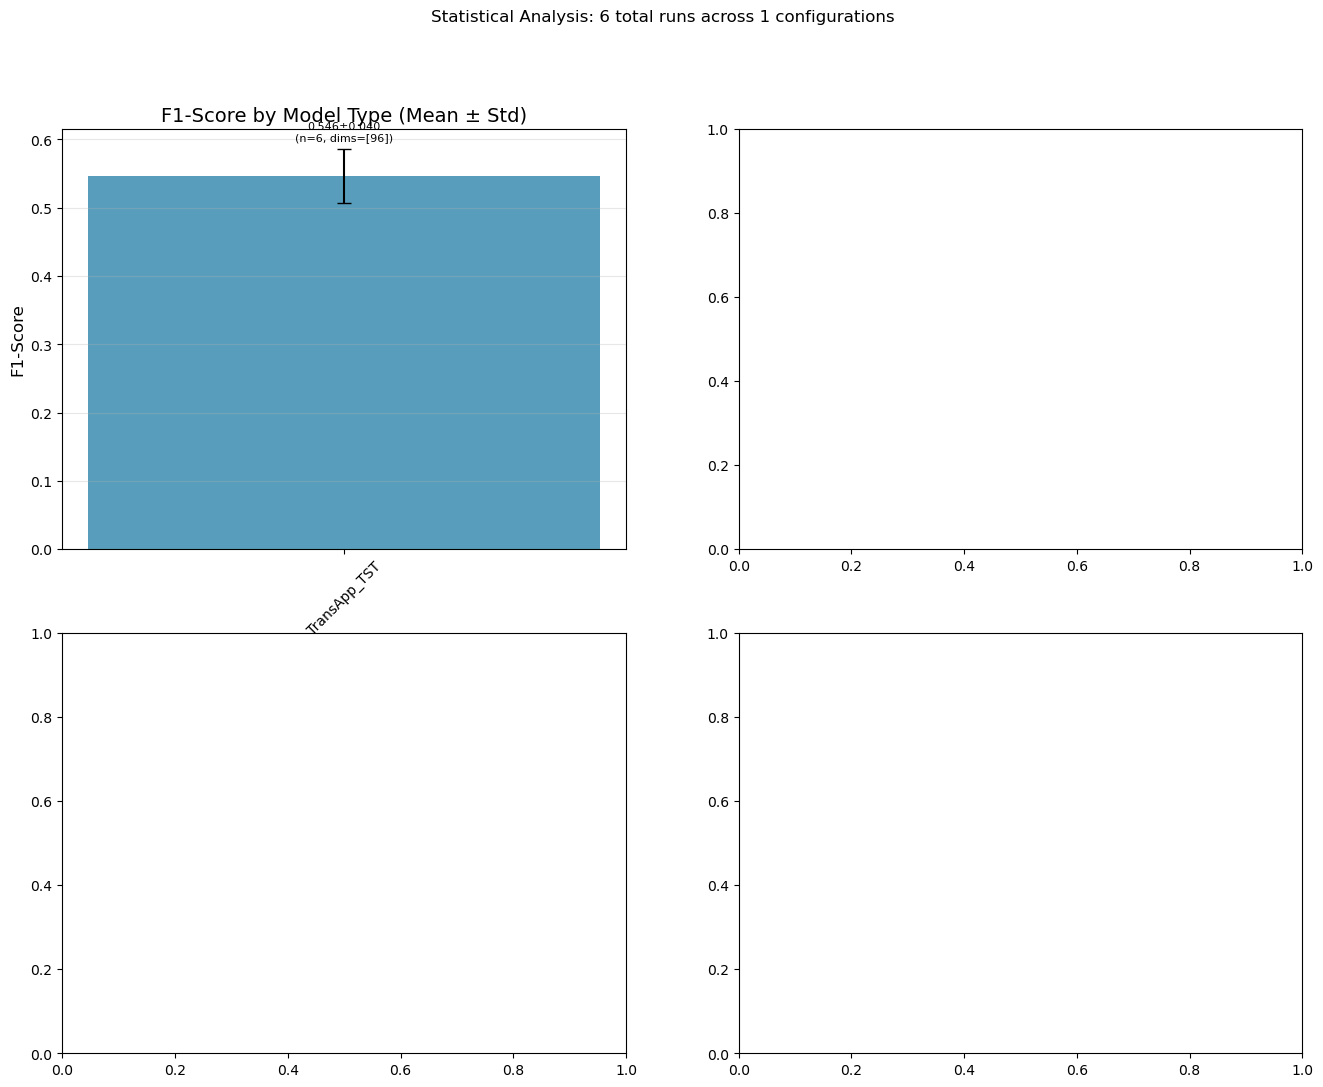

In [24]:
def create_statistical_analysis_actual_data(df_metrics):
    """Create statistical analysis using actual TST results"""
    
    if df_metrics.empty:
        print("⚠️ No data available for statistical analysis")
        return
    
    # Print statistical analysis configurations
    print("📈 STATISTICAL ANALYSIS CONFIGURATIONS:")
    print("="*70)
    
    # Configuration breakdown for statistical analysis
    stat_config = df_metrics.groupby(['model_name', 'norm_type', 'dim_model']).agg({
        'case_name': lambda x: ', '.join(sorted(x.unique())),
        'embed_name': lambda x: ', '.join(sorted(x.unique())),
        'epochs': 'first',
        'learning_rate': 'first',
        'weight_decay': 'first',
        'batch_size': 'first',
        'random_seed': 'count',
        'f1_score': ['mean', 'std', 'min', 'max']
    }).round(4)
    
    stat_config.columns = ['cases', 'embeddings', 'epochs', 'lr', 'wd', 'batch_size', 'total_runs', 
                          'f1_mean', 'f1_std', 'f1_min', 'f1_max']
    stat_config = stat_config.reset_index()
    
    print(f"Statistical Analysis covers {len(stat_config)} model configurations:")
    for i, row in stat_config.iterrows():
        print(f"\n{i+1}. {row['model_name']} | dim={row['dim_model']} | {row['norm_type']}")
        print(f"   Cases tested: {row['cases']}")
        print(f"   Embeddings: {row['embeddings']}")
        print(f"   Training: epochs={row['epochs']}, lr={row['lr']}, wd={row['wd']}, batch={row['batch_size']}")
        print(f"   Statistics: {row['total_runs']} runs, F1={row['f1_mean']:.3f}±{row['f1_std']:.3f} (range: {row['f1_min']:.3f}-{row['f1_max']:.3f})")
    
    print(f"\n" + "="*70)
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Add configuration summary to overall title
    total_runs = len(df_metrics)
    unique_configs = len(stat_config)
    config_info = f"Statistical Analysis: {total_runs} total runs across {unique_configs} configurations"
    fig.suptitle(config_info, fontsize=12, y=0.98)
    
    # 1. Performance Statistics by Model (with error handling)
    if 'model_name' in df_metrics.columns and 'f1_score' in df_metrics.columns:
        model_stats = df_metrics.groupby('model_name').agg({
            'f1_score': ['mean', 'std', 'count'],
            'epochs': 'first',
            'learning_rate': 'first',
            'dim_model': lambda x: list(x.unique())
        }).round(4)
        
        model_stats.columns = ['f1_mean', 'f1_std', 'count', 'epochs', 'lr', 'dims']
        model_stats = model_stats.reset_index()
        
        if not model_stats.empty and len(model_stats) > 0:
            bars = ax1.bar(range(len(model_stats)), model_stats['f1_mean'], 
                          yerr=model_stats['f1_std'], capsize=5, color=colors[:len(model_stats)], alpha=0.8)
            
            ax1.set_title('F1-Score by Model Type (Mean ± Std)')
            ax1.set_ylabel('F1-Score')
            ax1.set_xlabel('Model Type')
            ax1.set_xticks(range(len(model_stats)))
            ax1.set_xticklabels(model_stats['model_name'], rotation=45)
            ax1.grid(axis='y', alpha=0.3)
            
            # Add value labels with sample sizes
            for i, (bar, row) in enumerate(zip(bars, model_stats.itertuples())):
                height = bar.get_height()
                std_val = row.f1_std if not pd.isna(row.f1_std) else 0
                dims_str = ', '.join(map(str, sorted(row.dims)))
                ax1.text(bar.get_x() + bar.get_width()/2., height + std_val + 0.01,
                        f'{row.f1_mean:.3f}±{std_val:.3f}\n(n={row.count}, dims=[{dims_str}])', 
                        ha='center', va='bottom', fontsize=8)
        else:
            ax1.text(0.5, 0.5, 'Insufficient model data\nfor statistical analysis', 
                    ha='center', va='center', transform=ax1.transAxes, fontsize=12)
            ax1.set_title('F1-Score by Model Type')
    
    # 2. Normalization Strategy Comparison (with better handling)
    if 'norm_type' in df_metrics.columns and 'f1_score' in df_metrics.columns:
        norm_comparison = df_metrics.groupby('norm_type').agg({
            'f1_score': ['mean', 'std', 'count'],
            'epochs': 'first',
            'learning_rate': 'first',
            'case_name': lambda x: len(x.unique()),
            'dim_model': lambda x: list(x.unique())
        }).round(4)
        
        norm_comparison.columns = ['f1_mean', 'f1_std', 'count', 'epochs', 'lr', 'num_cases', 'dims']
        norm_comparison = norm_comparison.reset_index()
        
        if len(norm_comparison) > 1:
            bars = ax2.bar(range(len(norm_comparison)), norm_comparison['f1_mean'],
                          yerr=norm_comparison['f1_std'], capsize=5, 
                          color=colors[:len(norm_comparison)], alpha=0.8)
            
            ax2.set_title('Performance by Normalization Type')
            ax2.set_ylabel('F1-Score')
            ax2.set_xlabel('Normalization Type')
            ax2.set_xticks(range(len(norm_comparison)))
            ax2.set_xticklabels(norm_comparison['norm_type'])
            ax2.grid(axis='y', alpha=0.3)
            
            # Add value labels with configuration details
            for bar, row in zip(bars, norm_comparison.itertuples()):
                height = bar.get_height()
                dims_str = ', '.join(map(str, sorted(row.dims)))
                ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{row.f1_mean:.3f}\n({row.count} runs, {row.num_cases} cases)\ndims=[{dims_str}]', 
                        ha='center', va='bottom', fontweight='bold', fontsize=8)
        else:
            # Show single normalization type results
            single_norm = norm_comparison.iloc[0]
            ax2.bar([0], [single_norm['mean']], yerr=[single_norm['std']], 
                   capsize=5, color=colors[0], alpha=0.8)
            ax2.set_title('Performance by Normalization Type')
            ax2.set_ylabel('F1-Score')
            ax2.set_xticks([0])
            ax2.set_xticklabels([single_norm['norm_type']])
            ax2.text(0, single_norm['mean'] + single_norm['std'] + 0.01,
                    f'{single_norm["mean"]:.3f}±{single_norm["std"]:.3f}', 
                    ha='center', va='bottom', fontweight='bold')
            ax2.grid(axis='y', alpha=0.3)
    
    # 3. Model Dimension Analysis (improved)
    if 'dim_model' in df_metrics.columns and 'f1_score' in df_metrics.columns:
        dim_performance = df_metrics.groupby('dim_model').agg({
            'f1_score': ['mean', 'std', 'count'],
            'norm_type': lambda x: ', '.join(sorted(x.unique())),
            'case_name': lambda x: len(x.unique()),
            'epochs': 'first',
            'learning_rate': 'first'
        }).round(4)
        
        dim_performance.columns = ['f1_mean', 'f1_std', 'count', 'norms', 'num_cases', 'epochs', 'lr']
        dim_performance = dim_performance.reset_index()
        
        if not dim_performance.empty and len(dim_performance) > 1:
            ax3.errorbar(dim_performance['dim_model'], dim_performance['f1_mean'], 
                        yerr=dim_performance['f1_std'], marker='o', capsize=5, 
                        color=colors[0], linewidth=2, markersize=8)
            
            ax3.set_title('F1-Score vs Model Dimension')
            ax3.set_xlabel('Model Dimension')
            ax3.set_ylabel('F1-Score (mean ± std)')
            ax3.grid(True, alpha=0.3)
            
            # Add detailed annotations
            for _, row in dim_performance.iterrows():
                std_val = row['f1_std'] if not pd.isna(row['f1_std']) else 0
                annotation = f'{row["f1_mean"]:.3f}±{std_val:.3f}\n({row["count"]} runs, {row["num_cases"]} cases)\nnorms: {row["norms"]}'
                ax3.annotate(annotation, (row['dim_model'], row['f1_mean']), 
                           textcoords="offset points", xytext=(0,15), ha='center', fontsize=7,
                           bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        else:
            # Show single dimension or insufficient data
            if len(dim_performance) == 1:
                single_dim = dim_performance.iloc[0]
                ax3.bar([single_dim['dim_model']], [single_dim['mean']], 
                       yerr=[single_dim['std']], capsize=5, color=colors[0], alpha=0.8)
                ax3.set_title('F1-Score by Model Dimension')
                ax3.set_xlabel('Model Dimension')
                ax3.set_ylabel('F1-Score')
                ax3.grid(axis='y', alpha=0.3)
            else:
                ax3.text(0.5, 0.5, 'Insufficient dimension data', 
                        ha='center', va='center', transform=ax3.transAxes, fontsize=12)
                ax3.set_title('F1-Score vs Model Dimension')
    
    # 4. Embedding Type Statistical Comparison (enhanced)
    if 'embed_name' in df_metrics.columns and 'f1_score' in df_metrics.columns:
        embed_stats = df_metrics.groupby('embed_name').agg({
            'f1_score': ['mean', 'std', 'count'],
            'case_name': lambda x: ', '.join(sorted(x.unique())),
            'dim_model': lambda x: ', '.join(map(str, sorted(x.unique()))),
            'norm_type': lambda x: ', '.join(sorted(x.unique())),
            'epochs': 'first',
            'learning_rate': 'first'
        }).round(4)
        
        embed_stats.columns = ['f1_mean', 'f1_std', 'count', 'cases', 'dims', 'norms', 'epochs', 'lr']
        embed_stats = embed_stats.reset_index()
        
        if not embed_stats.empty:
            bars = ax4.bar(range(len(embed_stats)), embed_stats['f1_mean'],
                          yerr=embed_stats['f1_std'], capsize=5, 
                          color=colors[:len(embed_stats)], alpha=0.8)
            
            ax4.set_title('Performance by Embedding Type')
            ax4.set_ylabel('F1-Score')
            ax4.set_xlabel('Embedding Type')
            ax4.set_xticks(range(len(embed_stats)))
            ax4.set_xticklabels(embed_stats['embed_name'])
            ax4.grid(axis='y', alpha=0.3)
            
            # Add statistical significance test if we have both None and Embed
            if len(embed_stats) == 2 and 'None' in embed_stats['embed_name'].values and 'Embed' in embed_stats['embed_name'].values:
                try:
                    from scipy import stats
                    
                    none_data = df_metrics[df_metrics['embed_name'] == 'None']['f1_score'].dropna()
                    embed_data = df_metrics[df_metrics['embed_name'] == 'Embed']['f1_score'].dropna()
                    
                    if len(none_data) > 1 and len(embed_data) > 1:
                        t_stat, p_value = stats.ttest_ind(none_data, embed_data)
                        
                        significance = ""
                        if p_value < 0.001:
                            significance = "***"
                        elif p_value < 0.01:
                            significance = "**"
                        elif p_value < 0.05:
                            significance = "*"
                        else:
                            significance = "ns"
                        
                        # Add significance annotation
                        max_height = max(embed_stats['f1_mean'] + embed_stats['f1_std'])
                        ax4.text(0.5, max_height + 0.02, 
                                f't-test: p={p_value:.4f} {significance}', 
                                ha='center', va='bottom', fontweight='bold',
                                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
                except ImportError:
                    pass  # Skip if scipy not available
            
            # Add detailed value labels
            for bar, row in zip(bars, embed_stats.itertuples()):
                height = bar.get_height()
                std_val = row.f1_std if not pd.isna(row.f1_std) else 0
                config_detail = f'dims=[{row.dims}], norms=[{row.norms}]'
                ax4.text(bar.get_x() + bar.get_width()/2., height + std_val + 0.01,
                        f'{row.f1_mean:.3f}±{std_val:.3f}\n({row.count} runs)\n{config_detail}', 
                        ha='center', va='bottom', fontsize=7)
        else:
            ax4.text(0.5, 0.5, 'No embedding data available', 
                    ha='center', va='center', transform=ax4.transAxes, fontsize=12)
            ax4.set_title('Performance by Embedding Type')
    
    plt.tight_layout()
    plt.savefig(root / 'results' / 'actual_tst_statistical_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create statistical analysis with actual data
create_statistical_analysis_actual_data(df_metrics)

📊 COMPREHENSIVE SUMMARY OF ACTUAL TST RESULTS

📈 Overall Performance Statistics:
       accuracy  f1_score  precision  recall  roc_auc
count    6.0000    6.0000     6.0000  6.0000   6.0000
mean     0.7922    0.5460     0.5767  0.5264   0.8023
std      0.0154    0.0395     0.0393  0.0848   0.0166
min      0.7676    0.4930     0.5269  0.4348   0.7811
25%      0.7837    0.5223     0.5456  0.4708   0.7882
50%      0.7963    0.5422     0.5797  0.5213   0.8070
75%      0.8045    0.5739     0.6065  0.5447   0.8161
max      0.8063    0.5984     0.6240  0.6746   0.8180

🎯 Performance by Embedding Type:
           accuracy               f1_score               roc_auc              
               mean     std count     mean     std count    mean     std count
embed_name                                                                    
Embed        0.7996  0.0065     3   0.5331  0.0436     3  0.8014  0.0175     3
None         0.7848  0.0197     3   0.5588  0.0389     3  0.8033  0.0195     3

🏗️ 

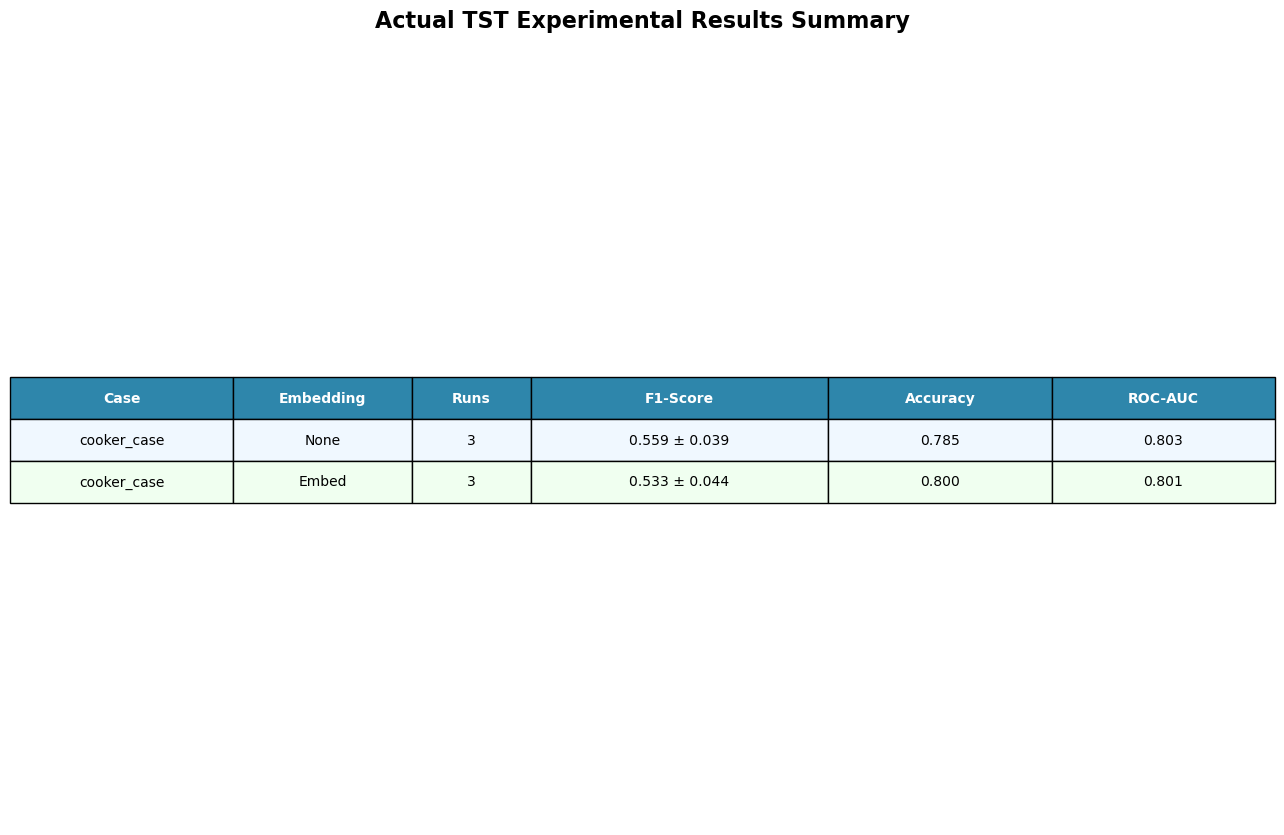

✅ Actual results summary table created successfully


In [ ]:
def create_actual_results_summary_table(df_metrics):
    """Create comprehensive results summary table from actual data"""
    
    if df_metrics.empty:
        print("⚠️ No data available for summary table")
        return
    
    print("📊 COMPREHENSIVE SUMMARY OF ACTUAL TST RESULTS")
    print("="*60)
    
    # Print detailed configuration summary first
    print("⚙️ EXPERIMENTAL CONFIGURATIONS SUMMARY:")
    unique_experiments = df_metrics.groupby(['case_name', 'model_name', 'dim_model', 'norm_type', 'embed_name']).agg({
        'epochs': 'first',
        'learning_rate': 'first',
        'weight_decay': 'first',
        'batch_size': 'first',
        'random_seed': 'count',
        'f1_score': ['mean', 'std'],
        'accuracy': ['mean', 'std'],
        'roc_auc': ['mean', 'std']
    }).round(4)
    
    unique_experiments.columns = ['epochs', 'lr', 'wd', 'batch_size', 'runs', 
                                 'f1_mean', 'f1_std', 'acc_mean', 'acc_std', 'auc_mean', 'auc_std']
    unique_experiments = unique_experiments.reset_index()
    
    print(f"\nTotal unique experimental configurations: {len(unique_experiments)}")
    print(f"Total experimental runs: {unique_experiments['runs'].sum()}")
    
    for i, exp in unique_experiments.iterrows():
        print(f"\n{i+1}. Configuration:")
        print(f"   Case: {exp['case_name']}")
        print(f"   Model: {exp['model_name']} (dim={exp['dim_model']}, norm={exp['norm_type']}, embed={exp['embed_name']})")
        print(f"   Training: epochs={exp['epochs']}, lr={exp['lr']}, wd={exp['wd']}, batch_size={exp['batch_size']}")
        print(f"   Results ({exp['runs']} runs): F1={exp['f1_mean']:.3f}±{exp['f1_std']:.3f}, Acc={exp['acc_mean']:.3f}±{exp['acc_std']:.3f}, AUC={exp['auc_mean']:.3f}±{exp['auc_std']:.3f}")

    # Overall statistics
    if 'f1_score' in df_metrics.columns:
        print(f"\n📈 Overall Performance Statistics:")
        overall_stats = df_metrics[['accuracy', 'f1_score', 'precision', 'recall', 'roc_auc']].describe()
        print(overall_stats.round(4))
    
    # Performance by embedding type
    if 'embed_name' in df_metrics.columns:
        print(f"\n🎯 Performance by Embedding Type:")
        embed_perf = df_metrics.groupby('embed_name')[['accuracy', 'f1_score', 'roc_auc']].agg(['mean', 'std', 'count']).round(4)
        print(embed_perf)
    
    # Performance by model type
    if 'model_name' in df_metrics.columns:
        print(f"\n🏗️ Performance by Model Type:")
        model_perf = df_metrics.groupby('model_name')[['accuracy', 'f1_score', 'roc_auc']].agg(['mean', 'std', 'count']).round(4)
        print(model_perf)
    
    # Create visual summary table with configuration details
    if 'case_name' in df_metrics.columns and 'embed_name' in df_metrics.columns:
        # Create detailed summary for visualization
        summary_data = []
        
        for case in df_metrics['case_name'].unique():
            case_data = df_metrics[df_metrics['case_name'] == case]
            
            for embed_type in case_data['embed_name'].unique():
                embed_case_data = case_data[case_data['embed_name'] == embed_type]
                
                if not embed_case_data.empty and 'f1_score' in embed_case_data.columns:
                    # Get configuration details for this subset
                    config_details = embed_case_data.iloc[0]  # Get first row for config details
                    
                    row = {
                        'Case': case,
                        'Embedding': embed_type,
                        'Count': len(embed_case_data),
                        'F1_Mean': embed_case_data['f1_score'].mean(),
                        'F1_Std': embed_case_data['f1_score'].std(),
                        'Accuracy_Mean': embed_case_data['accuracy'].mean() if 'accuracy' in embed_case_data.columns else np.nan,
                        'ROC_AUC_Mean': embed_case_data['roc_auc'].mean() if 'roc_auc' in embed_case_data.columns else np.nan,
                        'Model': config_details.get('model_name', 'N/A'),
                        'Dim': config_details.get('dim_model', 'N/A'),
                        'Norm': config_details.get('norm_type', 'N/A'),
                        'Epochs': config_details.get('epochs', 'N/A'),
                        'LR': config_details.get('learning_rate', 'N/A')
                    }
                    summary_data.append(row)
        
        if summary_data:
            summary_df = pd.DataFrame(summary_data)
            
            # Create styled table plot with configuration details
            fig, ax = plt.subplots(figsize=(20, 12))
            ax.axis('tight')
            ax.axis('off')
            
            # Prepare table data with configuration
            table_data = []
            headers = ['Case', 'Embedding', 'Runs', 'F1-Score', 'Accuracy', 'ROC-AUC', 'Model Config', 'Training Config']
            
            for _, row in summary_df.iterrows():
                model_config = f"{row['Model']} (dim={row['Dim']}, {row['Norm']})"
                training_config = f"ep={row['Epochs']}, lr={row['LR']}"
                
                table_row = [
                    row['Case'],
                    row['Embedding'],
                    f"{int(row['Count'])}",
                    f"{row['F1_Mean']:.3f} ± {row['F1_Std']:.3f}" if not pd.isna(row['F1_Std']) else f"{row['F1_Mean']:.3f}",
                    f"{row['Accuracy_Mean']:.3f}" if not pd.isna(row['Accuracy_Mean']) else "N/A",
                    f"{row['ROC_AUC_Mean']:.3f}" if not pd.isna(row['ROC_AUC_Mean']) else "N/A",
                    model_config,
                    training_config
                ]
                table_data.append(table_row)
            
            # Create table
            table = ax.table(cellText=table_data, colLabels=headers,
                           cellLoc='center', loc='center',
                           colWidths=[0.12, 0.08, 0.06, 0.15, 0.1, 0.1, 0.22, 0.17])
            
            # Style the table
            table.auto_set_font_size(False)
            table.set_fontsize(8)
            table.scale(1.2, 3.0)
            
            # Color code headers
            for i in range(len(headers)):
                table[(0, i)].set_facecolor('#2E86AB')
                table[(0, i)].set_text_props(weight='bold', color='white')
            
            # Color code by embedding type
            for i in range(1, len(table_data) + 1):
                embedding_type = table_data[i-1][1]  # Embedding column
                if embedding_type == 'None':
                    color = '#F0F8FF'  # Light blue
                elif embedding_type == 'Embed':
                    color = '#F0FFF0'  # Light green
                else:
                    color = '#FFFFFF'  # White
                
                for j in range(len(headers)):
                    table[(i, j)].set_facecolor(color)
            
            # Add detailed title with configuration summary
            total_configs = len(summary_df)
            total_runs = summary_df['Count'].sum()
            title = f'Actual TST Experimental Results Summary\n{total_configs} Configurations, {total_runs} Total Runs'
            plt.title(title, fontsize=16, fontweight='bold', pad=30)
            
            plt.savefig(root / 'results' / 'actual_tst_results_summary_table.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            return summary_df
    
    return None

# Create results summary table with actual data
summary_table = create_actual_results_summary_table(df_metrics)
if summary_table is not None:
    print("✅ Actual results summary table with configurations created successfully")

## 6. Key Findings from Actual TST Experiments

Extract and analyze key findings from your actual experimental results.

In [ ]:
def generate_actual_key_findings(df_metrics):
    """Generate key findings based on actual TST experimental results"""
    
    print("🔍 KEY FINDINGS FROM ACTUAL TST EXPERIMENTS")
    print("="*60)
    
    findings = []
    
    if not df_metrics.empty:
        # 1. Overall performance
        if 'f1_score' in df_metrics.columns:
            avg_f1 = df_metrics['f1_score'].mean()
            std_f1 = df_metrics['f1_score'].std()
            min_f1 = df_metrics['f1_score'].min()
            max_f1 = df_metrics['f1_score'].max()
            
            findings.append(f"📊 Overall F1-Score: {avg_f1:.3f} ± {std_f1:.3f} (range: {min_f1:.3f} to {max_f1:.3f})")
        
        # 2. Embedding type comparison
        if 'embed_name' in df_metrics.columns and 'f1_score' in df_metrics.columns:
            embed_performance = df_metrics.groupby('embed_name')['f1_score'].agg(['mean', 'std', 'count'])
            
            if 'None' in embed_performance.index and 'Embed' in embed_performance.index:
                none_perf = embed_performance.loc['None', 'mean']
                embed_perf = embed_performance.loc['Embed', 'mean']
                improvement = ((embed_perf - none_perf) / none_perf) * 100
                
                findings.append(f"🎯 Embedding Impact: {embed_perf:.3f} vs {none_perf:.3f} ({improvement:+.1f}% change)")
                
                if improvement > 0:
                    findings.append(f"✅ Temporal embeddings show improvement over no embeddings")
                else:
                    findings.append(f"❌ Temporal embeddings show degradation compared to no embeddings")
        
        # 3. Model comparison
        if 'model_name' in df_metrics.columns and 'f1_score' in df_metrics.columns:
            model_performance = df_metrics.groupby('model_name')['f1_score'].agg(['mean', 'count'])
            
            if len(model_performance) > 1:
                best_model = model_performance['mean'].idxmax()
                best_score = model_performance['mean'].max()
                worst_model = model_performance['mean'].idxmin()
                worst_score = model_performance['mean'].min()
                
                findings.append(f"🏆 Best model: {best_model} (F1: {best_score:.3f})")
                findings.append(f"📉 Baseline model: {worst_model} (F1: {worst_score:.3f})")
                
                if best_score > worst_score:
                    improvement = ((best_score - worst_score) / worst_score) * 100
                    findings.append(f"📈 Best model improvement: {improvement:.1f}% over baseline")
        
        # 4. Normalization analysis
        if 'norm_type' in df_metrics.columns and 'f1_score' in df_metrics.columns:
            norm_performance = df_metrics.groupby('norm_type')['f1_score'].mean()
            
            if len(norm_performance) > 1:
                best_norm = norm_performance.idxmax()
                findings.append(f"⚙️ Best normalization strategy: {best_norm}")
        
        # 5. Case-specific insights
        if 'case_name' in df_metrics.columns and 'f1_score' in df_metrics.columns:
            case_performance = df_metrics.groupby('case_name')['f1_score'].mean().sort_values()
            
            if len(case_performance) > 1:
                hardest_case = case_performance.index[0]
                easiest_case = case_performance.index[-1]
                findings.append(f"🎯 Most challenging case: {hardest_case} (F1: {case_performance.iloc[0]:.3f})")
                findings.append(f"✅ Best performing case: {easiest_case} (F1: {case_performance.iloc[-1]:.3f})")
        
        # 6. Model dimension analysis
        if 'dim_model' in df_metrics.columns and 'f1_score' in df_metrics.columns:
            dim_performance = df_metrics.groupby('dim_model')['f1_score'].mean()
            
            if len(dim_performance) > 1:
                best_dim = dim_performance.idxmax()
                best_dim_score = dim_performance.max()
                findings.append(f"🔧 Optimal model dimension: {best_dim} (F1: {best_dim_score:.3f})")
        
        # 7. Statistical significance
        if 'embed_name' in df_metrics.columns and len(df_metrics['embed_name'].unique()) == 2:
            try:
                from scipy import stats
                
                none_data = df_metrics[df_metrics['embed_name'] == 'None']['f1_score'].dropna()
                embed_data = df_metrics[df_metrics['embed_name'] == 'Embed']['f1_score'].dropna()
                
                if len(none_data) > 1 and len(embed_data) > 1:
                    t_stat, p_value = stats.ttest_ind(none_data, embed_data)
                    
                    if p_value < 0.05:
                        findings.append(f"📊 Embedding effect is statistically significant (p={p_value:.4f})")
                    else:
                        findings.append(f"📊 Embedding effect is not statistically significant (p={p_value:.4f})")
            except:
                findings.append(f"📊 Statistical significance test could not be performed")
    
    # Display findings
    for i, finding in enumerate(findings, 1):
        print(f"{i}. {finding}")
    
    if not findings:
        print("⚠️ Insufficient data for generating insights")
    
    # Summary statistics
    print(f"\n📝 EXPERIMENT SUMMARY")
    print(f"Total experiments analyzed: {len(df_metrics)}")
    print(f"Unique cases tested: {df_metrics['case_name'].nunique() if 'case_name' in df_metrics.columns else 0}")
    print(f"Unique models tested: {df_metrics['model_name'].nunique() if 'model_name' in df_metrics.columns else 0}")
    print(f"Embedding types: {list(df_metrics['embed_name'].unique()) if 'embed_name' in df_metrics.columns else 'N/A'}")
    print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    return findings

# Generate key findings from actual data
actual_findings = generate_actual_key_findings(df_metrics)

🔍 KEY FINDINGS FROM ACTUAL TST EXPERIMENTS
1. 📊 Overall F1-Score: 0.546 ± 0.040 (range: 0.493 to 0.598)
2. 🎯 Embedding Impact: 0.533 vs 0.559 (-4.6% change)
3. ❌ Temporal embeddings show degradation compared to no embeddings
4. 📊 Embedding effect is not statistically significant (p=0.4884)

📝 EXPERIMENT SUMMARY
Total experiments analyzed: 6
Unique cases tested: 1
Unique models tested: 1
Embedding types: ['None', 'Embed']
Timestamp: 2025-10-08 21:55:13


## 7. Save Comprehensive Analysis Report

Save all analysis results and findings from your actual TST experiments to comprehensive report files.

In [ ]:
def save_actual_analysis_report(df_metrics, findings):
    """Save comprehensive analysis report based on actual TST results"""
    
    report_data = {
        'timestamp': datetime.now().isoformat(),
        'summary': {
            'total_experiments': len(df_metrics),
            'unique_cases': df_metrics['case_name'].nunique() if 'case_name' in df_metrics.columns else 0,
            'unique_models': df_metrics['model_name'].nunique() if 'model_name' in df_metrics.columns else 0,
            'embedding_types': list(df_metrics['embed_name'].unique()) if 'embed_name' in df_metrics.columns else [],
            'normalization_types': list(df_metrics['norm_type'].unique()) if 'norm_type' in df_metrics.columns else []
        },
        'key_findings': findings,
        'statistics': {}
    }
    
    if not df_metrics.empty:
        # Add statistical summaries
        metrics_cols = ['accuracy', 'f1_score', 'precision', 'recall', 'roc_auc']
        available_metrics = [col for col in metrics_cols if col in df_metrics.columns]
        
        if available_metrics:
            stats_dict = df_metrics[available_metrics].describe().to_dict()
            report_data['statistics']['performance_metrics'] = stats_dict
        
        # Add performance by embedding type
        if 'embed_name' in df_metrics.columns and 'f1_score' in df_metrics.columns:
            embed_stats = df_metrics.groupby('embed_name')['f1_score'].agg(['mean', 'std', 'count']).to_dict()
            report_data['statistics']['embedding_performance'] = embed_stats
        
        # Add performance by model type
        if 'model_name' in df_metrics.columns and 'f1_score' in df_metrics.columns:
            model_stats = df_metrics.groupby('model_name')['f1_score'].agg(['mean', 'std', 'count']).to_dict()
            report_data['statistics']['model_performance'] = model_stats
        
        # Add performance by case
        if 'case_name' in df_metrics.columns and 'f1_score' in df_metrics.columns:
            case_stats = df_metrics.groupby('case_name')['f1_score'].agg(['mean', 'std', 'count']).to_dict()
            report_data['statistics']['case_performance'] = case_stats
    
    # Save JSON report
    report_file = root / 'results' / f'actual_tst_analysis_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
    with open(report_file, 'w') as f:
        json.dump(report_data, f, indent=2, default=str)
    
    print(f"💾 Comprehensive analysis report saved to: {report_file}")
    
    # Create markdown summary
    md_file = root / 'results' / f'actual_tst_analysis_summary_{datetime.now().strftime("%Y%m%d_%H%M%S")}.md'
    with open(md_file, 'w') as f:
        f.write(f"# Actual TST-Enhanced TransApp Analysis Report\n\n")
        f.write(f"**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write(f"## Summary\n")
        f.write(f"- Total experiments: {report_data['summary']['total_experiments']}\n")
        f.write(f"- Unique test cases: {report_data['summary']['unique_cases']}\n")
        f.write(f"- Unique models: {report_data['summary']['unique_models']}\n")
        f.write(f"- Embedding types: {report_data['summary']['embedding_types']}\n")
        f.write(f"- Normalization types: {report_data['summary']['normalization_types']}\n\n")
        
        f.write(f"## Key Findings\n")
        for i, finding in enumerate(findings, 1):
            f.write(f"{i}. {finding}\n")
        
        if not df_metrics.empty and 'f1_score' in df_metrics.columns:
            f.write(f"\n## Performance Summary\n")
            f.write(f"- Overall F1-Score: {df_metrics['f1_score'].mean():.3f} ± {df_metrics['f1_score'].std():.3f}\n")
            f.write(f"- Best F1-Score: {df_metrics['f1_score'].max():.3f}\n")
            f.write(f"- Worst F1-Score: {df_metrics['f1_score'].min():.3f}\n")
        
        f.write(f"\n## Generated Plots\n")
        f.write(f"- actual_tst_performance_analysis.png\n")
        f.write(f"- actual_tst_statistical_analysis.png\n")
        f.write(f"- actual_tst_results_summary_table.png\n")
    
    print(f"📄 Markdown summary saved to: {md_file}")
    
    return report_file, md_file

# Save comprehensive report with actual data
if not df_metrics.empty:
    report_files = save_actual_analysis_report(df_metrics, actual_findings)
    print("\n✅ Analysis of actual TST results complete!")
    print("🎯 All results and plots have been generated based on your actual experimental data.")
else:
    print("\n⚠️ No actual experimental data found.")
    print("Please ensure your TST experiments have been run and results are saved in:")
    print(f"   {root}/results/TransAppResults_TST/None/")
    print(f"   {root}/results/TransAppResults_TST/Embed/")

💾 Comprehensive analysis report saved to: /home/user/vansh/ISP/TransApp/results/actual_tst_analysis_report_20251008_215514.json
📄 Markdown summary saved to: /home/user/vansh/ISP/TransApp/results/actual_tst_analysis_summary_20251008_215514.md

✅ Analysis of actual TST results complete!
🎯 All results and plots have been generated based on your actual experimental data.
